Generated 1000 random binary rewards
Reward distribution: 500 ones, 500 zeros

Running value learning algorithms...


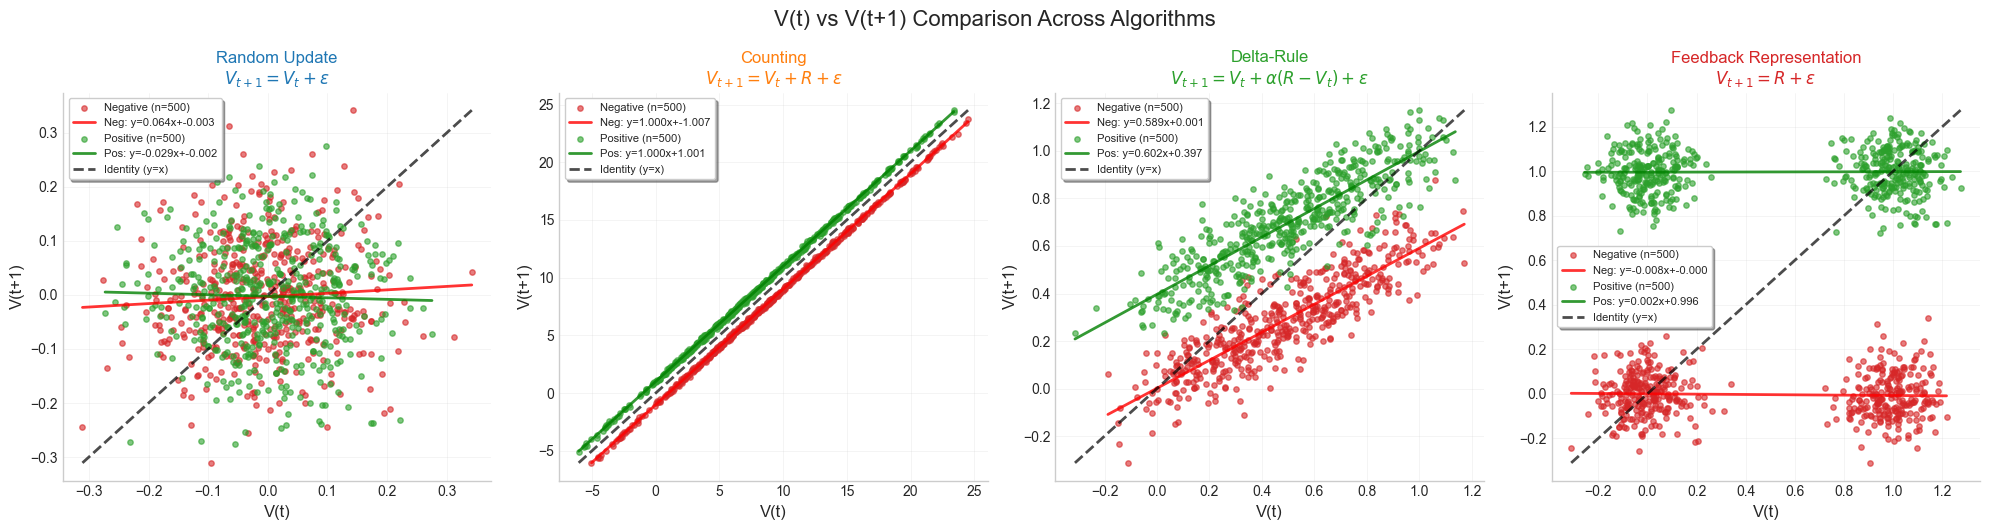

<Figure size 640x480 with 0 Axes>


SUMMARY COMPARISON (α = 0.05)
Algorithm            Outcome  n    Slope      Intercept    R²       Reg significant?  Slope flat?    Slope = identity?  Neg vs Pos intercept  
--------------------------------------------------------------------------------------------------------------------------------------------
Random Update        Positive  500  -0.0285    -0.0024      0.001    ✘                 ✔              ✘                  Neg = Pos             
                     Negative  500  0.0636     -0.0033      0.004    ✘                 ✔              ✘                                        

Counting             Positive  500  0.9995     1.0013       1.000    ✔                 ✘              ✔                  Neg < Pos             
                     Negative  500  1.0004     -1.0074      1.000    ✔                 ✘              ✔                                        

Delta-Rule           Positive  500  0.6015     0.3967       0.749    ✔                 ✘              ✘    

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

def generate_binary_rewards(n_trials, p_reward=0.5, seed=42):
    """Generate random binary rewards with specified probability."""
    #np.random.seed(seed)
    return np.random.binomial(1, p_reward, n_trials)

def run_value_learning_algorithms(rewards, alpha=0.4, noise_std=0.05, initial_value=0):
    """
    Run all four value learning algorithms on the given rewards.
    """
    n_trials = len(rewards)
    #np.random.seed(42)  # For reproducible noise
    
    algorithms = {
        'Random Update': np.zeros(n_trials + 1),
        'Counting': np.zeros(n_trials + 1),
        'Delta-Rule': np.zeros(n_trials + 1),
        'Feedback Representation': np.zeros(n_trials + 1)
    }
    for alg in algorithms:
        algorithms[alg][0] = initial_value
    
    for t in range(n_trials):
        R = rewards[t]
        noise = np.random.normal(0, noise_std)
        
        # 1) Random update: V(t+1) = V(t) + noise
        algorithms['Random Update'][t+1] = noise
        
        # 2) Counting: V(t+1) = V(t) + reward_signal + noise
        reward_signal = 1 if R == 1 else -1
        algorithms['Counting'][t+1] = algorithms['Counting'][t] + reward_signal + noise
        
        # 3) Delta-rule: V(t+1) = V(t) + alpha * RPE + noise
        rpe = R - algorithms['Delta-Rule'][t]
        algorithms['Delta-Rule'][t+1] = algorithms['Delta-Rule'][t] + alpha * rpe + noise
        
        # 4) Feedback representation: V(t) = R + noise
        algorithms['Feedback Representation'][t+1] = R + noise
    
    return algorithms

def fit_regression_and_test(v_t, v_t1):
    """
    Fit linear regression and perform statistical tests.
    Returns a dict with slope, intercept, tests, r_squared, and overall model significance.
    """
    if len(v_t) <= 1:
        return {
            'slope': np.nan, 'intercept': np.nan,
            'p_slope_gt0': np.nan, 'p_slope_lt1': np.nan,
            'p_slope_eq0_two': np.nan, 'p_slope_eq1_two': np.nan,
            'p_intercept_eq0_two': np.nan,
            'r_squared': np.nan, 'std_err': np.nan,
            'se_intercept': np.nan, 'df': np.nan,
            # NEW:
            'f_stat': np.nan, 'p_model': np.nan, 'n': len(v_t)
        }
    
    # Fit regression
    reg = LinearRegression().fit(v_t.reshape(-1, 1), v_t1)
    slope = reg.coef_[0]
    intercept = reg.intercept_
    r_squared = reg.score(v_t.reshape(-1, 1), v_t1)
    
    # Use scipy linregress for SE of slope
    _, _, _, _, std_err = stats.linregress(v_t, v_t1)
    
    # Degrees of freedom
    n = len(v_t)
    df = n - 2
    
    # One-/two-tailed slope tests (keep for table)
    t_gt0 = slope / std_err if std_err > 0 else np.nan
    p_slope_gt0 = 1 - stats.t.cdf(t_gt0, df) if np.isfinite(t_gt0) else np.nan  # H1: slope > 0
    t_lt1 = (slope - 1) / std_err if std_err > 0 else np.nan
    p_slope_lt1 = stats.t.cdf(t_lt1, df) if np.isfinite(t_lt1) else np.nan      # H1: slope < 1
    # Equality tests for slope
    p_slope_eq0_two = 2 * (1 - stats.t.cdf(abs(t_gt0), df)) if np.isfinite(t_gt0) else np.nan  # H0: slope = 0
    p_slope_eq1_two = 2 * (1 - stats.t.cdf(abs(t_lt1), df)) if np.isfinite(t_lt1) else np.nan  # H0: slope = 1
    
    # Intercept SE (standard OLS formula using residual variance)
    residuals = v_t1 - (slope * v_t + intercept)
    s2 = np.sum(residuals**2) / df if df > 0 else np.nan
    x = v_t
    x_bar = np.mean(x)
    Sxx = np.sum((x - x_bar)**2)
    se_intercept = np.sqrt(s2 * (1/len(x) + x_bar**2 / Sxx)) if (Sxx > 0 and np.isfinite(s2)) else np.nan
    # Equality test for intercept = 0 (still useful if you want to keep elsewhere)
    t_int = intercept / se_intercept if se_intercept and se_intercept > 0 else np.nan
    p_intercept_eq0_two = (2 * (1 - stats.t.cdf(abs(t_int), df))) if np.isfinite(t_int) else np.nan

    # === NEW: Overall regression significance (F-test, 1 and n-2 df) ===
    if df > 0 and np.isfinite(r_squared):
        if r_squared >= 1.0:
            f_stat = np.inf
            p_model = 0.0
        elif r_squared <= 0.0:
            f_stat = 0.0
            p_model = 1.0
        else:
            f_stat = (r_squared / (1 - r_squared)) * df
            p_model = 1 - stats.f.cdf(f_stat, 1, df)
    else:
        f_stat = np.nan
        p_model = np.nan
    
    return {
        'slope': slope, 'intercept': intercept,
        'p_slope_gt0': p_slope_gt0, 'p_slope_lt1': p_slope_lt1,
        'p_slope_eq0_two': p_slope_eq0_two, 'p_slope_eq1_two': p_slope_eq1_two,
        'p_intercept_eq0_two': p_intercept_eq0_two,
        'r_squared': r_squared, 'std_err': std_err,
        'se_intercept': se_intercept, 'df': df,
        # NEW fields:
        'f_stat': f_stat, 'p_model': p_model, 'n': n
    }

def analyze_single_algorithm(v_t, v_t1, rewards, algorithm_name):
    """
    Analyze a single value learning algorithm (no printing).
    """
    # Separate positive and negative outcomes
    pos_mask = rewards == 1
    neg_mask = rewards == 0
    
    v_t_pos = v_t[pos_mask]
    v_t1_pos = v_t1[pos_mask]
    v_t_neg = v_t[neg_mask]
    v_t1_neg = v_t1[neg_mask]
    
    # Fit regressions
    pos_results = fit_regression_and_test(v_t_pos, v_t1_pos)
    neg_results = fit_regression_and_test(v_t_neg, v_t1_neg)
    
    return {
        'positive': pos_results,
        'negative': neg_results,
        'v_t_pos': v_t_pos, 'v_t1_pos': v_t1_pos,
        'v_t_neg': v_t_neg, 'v_t1_neg': v_t1_neg
    }

def despine_axis(ax):
    """Remove top and right spines from axis."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1)
    ax.spines['bottom'].set_linewidth(1)

def plot_vt_vs_vt1_comparison(algorithms_data, rewards):
    """
    Plot V(t) vs V(t+1) for all four algorithms in a single row.
    """
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    algorithm_names = ['Random Update', 'Counting', 'Delta-Rule', 'Feedback Representation']
    rules = [
        r"$V_{t+1} = V_t + \varepsilon$",
        r"$V_{t+1} = V_t + R + \varepsilon$",
        r"$V_{t+1} = V_t + \alpha (R - V_t) + \varepsilon$",
        r"$V_{t+1} = R + \varepsilon$"
    ]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    for idx, (alg_name, rule, color) in enumerate(zip(algorithm_names, rules, colors)):
        ax = axes[idx]
        values = algorithms_data[alg_name]
        v_t = values[:-1]
        v_t1 = values[1:]
        
        analysis = analyze_single_algorithm(v_t, v_t1, rewards, alg_name)
        
        # Plot negative outcomes (red)
        if len(analysis['v_t_neg']) > 0:
            ax.scatter(analysis['v_t_neg'], analysis['v_t1_neg'], 
                       c='tab:red', alpha=0.6, s=15, label=f'Negative (n={len(analysis["v_t_neg"])})')
            if not np.isnan(analysis['negative']['slope']):
                x_range = np.linspace(np.min(analysis['v_t_neg']), np.max(analysis['v_t_neg']), 100)
                y_fit = analysis['negative']['slope'] * x_range + analysis['negative']['intercept']
                ax.plot(x_range, y_fit, 'r-', linewidth=2, alpha=0.8,
                        label=f'Neg: y={analysis["negative"]["slope"]:.3f}x+{analysis["negative"]["intercept"]:.3f}')
        
        # Plot positive outcomes (green)
        if len(analysis['v_t_pos']) > 0:
            ax.scatter(analysis['v_t_pos'], analysis['v_t1_pos'], 
                       c='tab:green', alpha=0.6, s=15, label=f'Positive (n={len(analysis["v_t_pos"])})')
            if not np.isnan(analysis['positive']['slope']):
                x_range = np.linspace(np.min(analysis['v_t_pos']), np.max(analysis['v_t_pos']), 100)
                y_fit = analysis['positive']['slope'] * x_range + analysis['positive']['intercept']
                ax.plot(x_range, y_fit, 'g-', linewidth=2, alpha=0.8,
                        label=f'Pos: y={analysis["positive"]["slope"]:.3f}x+{analysis["positive"]["intercept"]:.3f}')
        
        # Identity line
        all_v = np.concatenate([v_t])
        if len(all_v) > 0:
            min_val, max_val = np.min(all_v), np.max(all_v)
            ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, alpha=0.7, label='Identity (y=x)')

        # Title now includes the rule
        ax.set_title(f"{alg_name}\n{rule}", fontsize=12, color=color)
        ax.set_xlabel('V(t)', fontsize=12)
        ax.set_ylabel('V(t+1)', fontsize=12)
        ax.legend(fontsize=8, frameon=True, fancybox=True, shadow=True)
        ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
        despine_axis(ax)
    
    plt.tight_layout()
    plt.suptitle('V(t) vs V(t+1) Comparison Across Algorithms', fontsize=16, y=1.05)
    plt.show()
    
    plt.tight_layout()
    plt.suptitle('V(t) vs V(t+1) Comparison Across Algorithms', fontsize=16, y=1.02)
    plt.show()

def plot_value_trajectories(algorithms_data, n_show=1000):
    """Plot value trajectories over time in a single row."""
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    
    algorithm_names = ['Random Update', 'Counting', 'Delta-Rule', 'Feedback Representation']
    rules = [
        r"$V_{t+1} = V_t + \varepsilon$",
        r"$V_{t+1} = V_t + R + \varepsilon$",
        r"$V_{t+1} = V_t + \alpha (R - V_t) + \varepsilon$",
        r"$V_{t+1} = R + \varepsilon$"
    ]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # (fix if copy/paste glitch)
    
    for idx, (alg_name, rule, color) in enumerate(zip(algorithm_names, rules, colors)):
        ax = axes[idx]
        values = algorithms_data[alg_name][:n_show]
        
        ax.plot(values, color=color, alpha=0.8, linewidth=1.5)
        ax.set_title(f"{alg_name}\n{rule}", fontsize=12, color=color)
        ax.set_xlabel('Trial', fontsize=12)
        ax.set_ylabel('Value', fontsize=12)
        ax.grid(True, alpha=0.3)
        despine_axis(ax)
    
    plt.tight_layout()
    plt.suptitle('Value Learning Trajectories', fontsize=16, y=1.05)
    plt.show()

def create_summary_table(all_results, alpha=0.05):
    """
    Summary with:
      - Overall regression significance (F-test, first check)
      - Slope flat?         -> slope ≈ 0 (two-tailed)      ✔ if NOT significantly different from 0
      - Slope = identity?   -> slope ≈ 1 (two-tailed)      ✔ if NOT significantly different from 1
      - Neg vs Pos intercept -> "Neg < Pos", "Neg = Pos", or "Neg > Pos" (two-tailed Welch test)
    """
    def mark_nonsig(p):
        if np.isnan(p): return "NaN"
        return "✔" if p >= alpha else "✘"

    # NEW: mark significant (for overall model)
    def mark_sig(p):
        if np.isnan(p): return "NaN"
        return "✔" if p < alpha else "✘"

    def intercept_relation(pos, neg):
        b0_pos, se_pos, df_pos = pos['intercept'], pos['se_intercept'], pos['df']
        b0_neg, se_neg, df_neg = neg['intercept'], neg['se_intercept'], neg['df']
        if any(np.isnan(x) for x in [b0_pos, se_pos, df_pos, b0_neg, se_neg, df_neg]):
            return "NaN"
        diff = b0_neg - b0_pos
        se_diff = np.sqrt(se_pos**2 + se_neg**2)  # independent groups
        if se_diff <= 0:
            return "NaN"
        t = diff / se_diff
        # Welch–Satterthwaite df
        v1, v2 = se_pos**2, se_neg**2
        df = ((v1 + v2)**2) / ((v1**2)/(df_pos) + (v2**2)/(df_neg)) if (df_pos > 0 and df_neg > 0) else (df_pos + df_neg)
        if not np.isfinite(df) or df <= 0:
            return "NaN"
        p_two = 2 * (1 - stats.t.cdf(abs(t), df))
        if p_two >= alpha:
            return "Neg = Pos"
        return "Neg < Pos" if diff < 0 else "Neg > Pos"

    print("\n" + "="*140)
    print(f"SUMMARY COMPARISON (α = {alpha:.2f})")
    print("="*140)
    print(f"{'Algorithm':<20} {'Outcome':<8} {'n':<4} {'Slope':<10} {'Intercept':<12} {'R²':<8} "
          f"{'Reg significant?':<17} {'Slope flat?':<14} {'Slope = identity?':<18} {'Neg vs Pos intercept':<22}")
    print("-"*140)

    for alg_name, results in all_results.items():
        display_name = "Feedback" if alg_name == "Feedback Representation" else alg_name
        pos = results['positive']
        neg = results['negative']
        rel = intercept_relation(pos, neg)

        print(
            f"{display_name:<20} Positive  {pos['n']:<4d} {pos['slope']:<10.4f} {pos['intercept']:<12.4f} {pos['r_squared']:<8.3f} "
            f"{mark_sig(pos['p_model']):<17} {mark_nonsig(pos['p_slope_eq0_two']):<14} {mark_nonsig(pos['p_slope_eq1_two']):<18} {rel:<22}"
        )
        print(
            f"{'':<20} Negative  {neg['n']:<4d} {neg['slope']:<10.4f} {neg['intercept']:<12.4f} {neg['r_squared']:<8.3f} "
            f"{mark_sig(neg['p_model']):<17} {mark_nonsig(neg['p_slope_eq0_two']):<14} {mark_nonsig(neg['p_slope_eq1_two']):<18} {'':<22}"
        )
        print()

# ============================================================================
# MAIN EXECUTION
# ============================================================================

# Parameters
n_trials = 1000
alpha = 0.4
noise_std = .1
initial_value = 0

# Generate rewards
rewards = generate_binary_rewards(n_trials)
print(f"Generated {n_trials} random binary rewards")
print(f"Reward distribution: {np.sum(rewards)} ones, {n_trials - np.sum(rewards)} zeros")

# Run algorithms
print("\nRunning value learning algorithms...")
algorithms_data = run_value_learning_algorithms(rewards, alpha, noise_std, initial_value)

# Analyze each algorithm (no per-model printing)
all_results = {}
algorithm_names = ['Random Update', 'Counting', 'Delta-Rule', 'Feedback Representation']

for alg_name in algorithm_names:
    values = algorithms_data[alg_name]
    v_t = values[:-1]
    v_t1 = values[1:]
    all_results[alg_name] = analyze_single_algorithm(v_t, v_t1, rewards, alg_name)

# Create visualizations (titles not bold)
plot_vt_vs_vt1_comparison(algorithms_data, rewards)
#plot_value_trajectories(algorithms_data)

# Summary table only
create_summary_table(all_results)
print(f"\nSimulation completed successfully!")
print(f"Processed {n_trials} trials with {np.sum(rewards)} positive and {n_trials - np.sum(rewards)} negative outcomes.")
